# Partie I — Perceptron Multi-Couches (MLP)
## Données tabulaires : Breast Cancer Wisconsin

**Objectif :** classifier des cellules (maligne / bénigne) à partir de 30 caractéristiques issues d'images de cytoponction (569 patientes).

**Concepts illustrés :**
- Deux implémentations du MLP : `nn.Sequential` vs classe personnalisée `nn.Module`
- Trois stratégies d'initialisation : gaussienne, constante (pédagogique), Xavier
- Boucle d'entraînement avec early stopping et sauvegarde du meilleur modèle
- Anti data leakage : `StandardScaler` ajusté sur le train uniquement
- Comparaison avec des baselines classiques (régression logistique, forêt aléatoire)

> **Résultats attendus :** `results/part1/` — 4 figures PNG + `metrics.json`

In [1]:
%matplotlib inline
import json
import numpy as np
import torch
from torch import nn
from copy import deepcopy
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# --- chemins (le notebook se trouve dans notebooks/, ROOT = projet_dl/) ---
SEED = 42
ROOT   = Path.cwd().parent
FIG    = ROOT / "results" / "part1"
MODELS = ROOT / "models"
FIG.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

def set_seed(s=SEED):
    np.random.seed(s)
    torch.manual_seed(s)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device : {DEVICE}")

PyTorch 2.11.0+cpu | device : cpu


## 1. Préparation des données

**Point critique — anti-data leakage :**
Le `StandardScaler` est **ajusté (`.fit`) uniquement sur le train**, puis appliqué (`.transform`) aux trois ensembles.
Ajuster sur tout le dataset ferait fuiter l'information du test dans l'apprentissage.

Le paramètre `stratify` préserve la proportion des classes (≈63 % bénin) dans chaque sous-ensemble.

In [2]:
@dataclass
class TabularData:
    X_train: torch.Tensor;  y_train: torch.Tensor
    X_val:   torch.Tensor;  y_val:   torch.Tensor
    X_test:  torch.Tensor;  y_test:  torch.Tensor
    feature_names: list;    class_names: list

    @property
    def n_features(self): return self.X_train.shape[1]

    @property
    def n_classes(self): return int(torch.unique(self.y_train).numel())


def load_data(seed=42, val_size=0.15, test_size=0.15):
    bunch = load_breast_cancer()
    X, y = bunch.data.astype(np.float32), bunch.target.astype(np.int64)

    # 1) séparation test (jamais vu avant l'évaluation finale)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y)

    # 2) séparation validation à partir du reste
    val_ratio = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=seed, stratify=y_temp)

    # 3) normalisation : fit sur le TRAIN uniquement
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    to_t = lambda a: torch.tensor(a, dtype=torch.float32)
    to_l = lambda a: torch.tensor(a, dtype=torch.long)
    return TabularData(
        to_t(X_train), to_l(y_train),
        to_t(X_val),   to_l(y_val),
        to_t(X_test),  to_l(y_test),
        list(bunch.feature_names), list(bunch.target_names))


data = load_data(seed=SEED)
print(f"Train : {tuple(data.X_train.shape)} | Val : {tuple(data.X_val.shape)} | Test : {tuple(data.X_test.shape)}")
print(f"Classes : {data.class_names}  |  n_features = {data.n_features}")
for split, y in [("train", data.y_train), ("val", data.y_val), ("test", data.y_test)]:
    print(f"  proportion benigne ({split}) : {y.float().mean().item():.3f}")

Train : (397, 30) | Val : (86, 30) | Test : (86, 30)
Classes : [np.str_('malignant'), np.str_('benign')]  |  n_features = 30
  proportion benigne (train) : 0.627
  proportion benigne (val) : 0.628
  proportion benigne (test) : 0.628


## 2. Architecture du modèle MLP

Deux implémentations **équivalentes** du même réseau à une couche cachée :

| Version | Code | Avantage |
|---------|------|----------|
| `nn.Sequential` | déclaratif, liste de couches | concis, lisible |
| `MLPCustom` (classe) | hérite de `nn.Module` | contrôle total du `forward`, permet les branchements |

**Architecture :** `Linear(30→64)` → `ReLU` → `Dropout(0.3)` → `Linear(64→2)`
Le `Dropout` est une régularisation contre le surapprentissage (dataset petit : 569 exemples).

In [3]:
def build_mlp_sequential(n_features, n_classes, hidden=64):
    return nn.Sequential(
        nn.Linear(n_features, hidden),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(hidden, n_classes),
    )


class MLPCustom(nn.Module):
    def __init__(self, n_features, n_classes, hidden=64, p_drop=0.3):
        super().__init__()   # ne JAMAIS oublier cet appel
        self.hidden = nn.Linear(n_features, hidden)
        self.act    = nn.ReLU()
        self.drop   = nn.Dropout(p_drop)
        self.out    = nn.Linear(hidden, n_classes)

    def forward(self, x):
        h = self.drop(self.act(self.hidden(x)))
        return self.out(h)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def inspect_parameters(model):
    print("--- named_parameters() ---")
    for name, param in model.named_parameters():
        print(f"  {name:25s}  shape={tuple(param.shape)}  requires_grad={param.requires_grad}")
    print("--- cles de state_dict() ---")
    print(", ".join(model.state_dict().keys()))
    print(f"Total parametres apprenables : {count_parameters(model)}")


# Vérification : les deux implémentations ont le même nombre de paramètres
seq  = build_mlp_sequential(data.n_features, data.n_classes)
cust = MLPCustom(data.n_features, data.n_classes)

inspect_parameters(cust)
assert count_parameters(seq) == count_parameters(cust)
print(f"[OK] Sequential et Custom : meme nombre de parametres = {count_parameters(cust)}")

--- named_parameters() ---
  hidden.weight              shape=(64, 30)  requires_grad=True
  hidden.bias                shape=(64,)  requires_grad=True
  out.weight                 shape=(2, 64)  requires_grad=True
  out.bias                   shape=(2,)  requires_grad=True
--- cles de state_dict() ---
hidden.weight, hidden.bias, out.weight, out.bias
Total parametres apprenables : 2114
[OK] Sequential et Custom : meme nombre de parametres = 2114


## 3. Stratégies d'initialisation des poids

| Stratégie | Formule | Comportement |
|-----------|---------|--------------|
| **Gaussienne** | w ~ N(0, 0.01) | Petits poids → activations stables au départ |
| **Constante** | w = 1 | ⚠ Problème de symétrie : tous les neurones identiques → n'apprend pas vraiment |
| **Xavier** | Var(w) = 2/(fan_in + fan_out) | Adapte la variance au nombre de connexions → référence robuste |

La **constante** est incluse à titre pédagogique pour illustrer le **problème de symétrie**.

In [4]:
def init_gaussienne(module):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.01)
        nn.init.zeros_(module.bias)

def init_constante(module):
    # MAUVAIS en pratique : tous les neurones recoivent le meme gradient
    if isinstance(module, nn.Linear):
        nn.init.constant_(module.weight, 1.0)
        nn.init.zeros_(module.bias)

def init_xavier(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

INIT_STRATEGIES = {
    "gaussienne": init_gaussienne,
    "constante":  init_constante,
    "xavier":     init_xavier,
}

## 4. Boucle d'entraînement avec early stopping

**Points clés :**
- **Régularisation L2** via `weight_decay` dans Adam (pénalise les grands poids)
- **Early stopping** : si la perte de validation ne s'améliore plus pendant `patience` epochs → arrêt
- **Meilleur modèle** : on conserve une copie des poids (via `deepcopy`) correspondant à la meilleure validation, pas la dernière epoch
- **device** : toutes les données et le modèle doivent être sur le **même** device (piège GPU classique)

In [5]:
def train_model(model, data, *, lr=1e-3, epochs=200, patience=20,
               device=None, weight_decay=1e-4, verbose=False):
    device = device or DEVICE
    model  = model.to(device)
    Xtr, ytr = data.X_train.to(device), data.y_train.to(device)
    Xva, yva = data.X_val.to(device),   data.y_val.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history   = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val, best_state, wait = float("inf"), None, 0

    for epoch in range(epochs):
        # --- apprentissage ---
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(Xtr), ytr)
        loss.backward()
        optimizer.step()

        # --- validation (pas de gradient, dropout desactive) ---
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xva), yva).item()
            val_acc  = (model(Xva).argmax(1) == yva).float().mean().item()

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val - 1e-5:
            best_val, best_state, wait = val_loss, deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"  early stopping a l'epoch {epoch} (val_loss={best_val:.4f})")
                break

        if verbose and epoch % 25 == 0:
            print(f"  epoch {epoch:3d} | train {loss.item():.4f} | val {val_loss:.4f} | acc {val_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def evaluate(model, X, y, device=None):
    device = device or DEVICE
    model  = model.to(device).eval()
    preds  = model(X.to(device)).argmax(1).cpu().numpy()
    y_true = y.cpu().numpy()
    return {
        "accuracy":         accuracy_score(y_true, preds),
        "precision":        precision_score(y_true, preds, average="macro", zero_division=0),
        "recall":           recall_score(y_true, preds, average="macro", zero_division=0),
        "f1":               f1_score(y_true, preds, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, preds),
        "predictions":      preds,
    }


def save_model(model, path):
    torch.save(model.state_dict(), path)

def load_model(model_factory, path, device=None):
    device = device or DEVICE
    model  = model_factory().to(device)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.eval()
    return model

## 5. Comparaison des trois stratégies d'initialisation

In [6]:
init_results, init_histories = {}, {}
for name, init_fn in INIT_STRATEGIES.items():
    set_seed()
    model = MLPCustom(data.n_features, data.n_classes)
    model.apply(init_fn)
    model, hist = train_model(model, data, device=DEVICE)
    metrics = evaluate(model, data.X_val, data.y_val, device=DEVICE)
    init_results[name]   = metrics["accuracy"]
    init_histories[name] = hist
    print(f"  init {name:11s} -> val accuracy = {metrics['accuracy']:.4f}")

best_init = max(init_results, key=init_results.get)
print(f"  -> Meilleure initialisation : {best_init}")

  init gaussienne  -> val accuracy = 1.0000
  init constante   -> val accuracy = 0.9651
  init xavier      -> val accuracy = 0.9884
  -> Meilleure initialisation : gaussienne


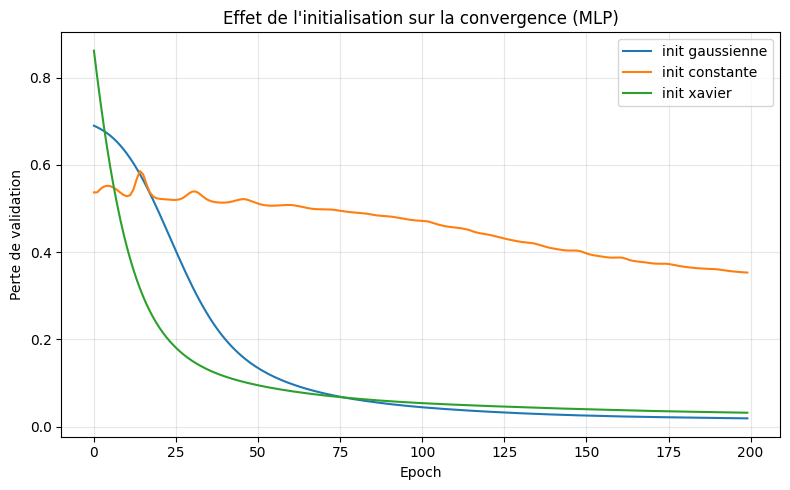

In [7]:
plt.figure(figsize=(8, 5))
for name, hist in init_histories.items():
    plt.plot(hist["val_loss"], label=f"init {name}")
plt.xlabel("Epoch")
plt.ylabel("Perte de validation")
plt.title("Effet de l'initialisation sur la convergence (MLP)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "init_comparison.png", dpi=120)

## 6. Entraînement final avec la meilleure initialisation

In [9]:
set_seed()
best_model = MLPCustom(data.n_features, data.n_classes)
best_model.apply(INIT_STRATEGIES[best_init])
best_model, history = train_model(best_model, data, device=DEVICE, verbose=True)

  epoch   0 | train 0.6934 | val 0.6900 | acc 0.860
  epoch  25 | train 0.4331 | val 0.4022 | acc 0.953
  epoch  50 | train 0.1791 | val 0.1343 | acc 0.977
  epoch  75 | train 0.1145 | val 0.0686 | acc 0.988
  epoch 100 | train 0.0893 | val 0.0446 | acc 1.000
  epoch 125 | train 0.0730 | val 0.0326 | acc 1.000
  epoch 150 | train 0.0659 | val 0.0255 | acc 1.000
  epoch 175 | train 0.0570 | val 0.0216 | acc 1.000


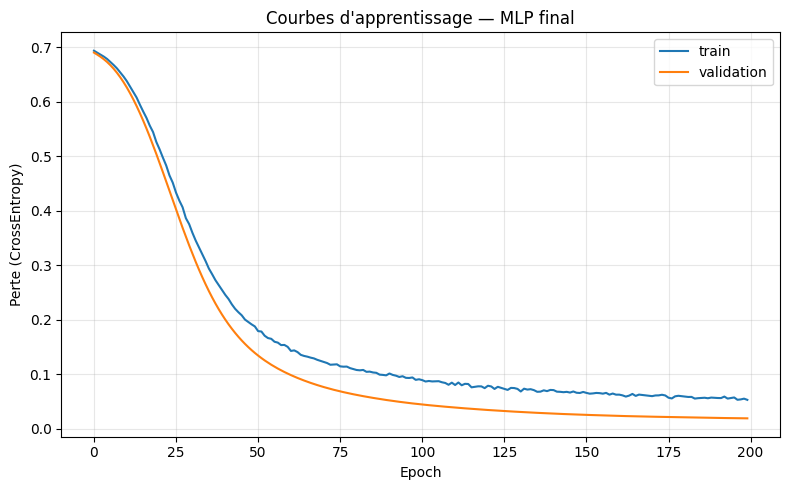

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"],   label="validation")
plt.xlabel("Epoch")
plt.ylabel("Perte (CrossEntropy)")
plt.title("Courbes d'apprentissage — MLP final")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "learning_curves.png", dpi=120)

## 7. Sauvegarde et rechargement du modèle

**Bonne pratique PyTorch :** on sauvegarde le `state_dict` (tenseurs des poids), pas l'objet modèle entier.
Pour recharger : (1) recréer l'architecture, (2) injecter les poids avec `load_state_dict`.
On vérifie que les métriques avant/après rechargement sont **identiques**.

In [11]:
save_model(best_model, MODELS / "mlp_best.pt")

reloaded = load_model(
    lambda: MLPCustom(data.n_features, data.n_classes),
    MODELS / "mlp_best.pt",
    device=DEVICE,
)

m_before = evaluate(best_model, data.X_test, data.y_test, device=DEVICE)
m_after  = evaluate(reloaded,   data.X_test, data.y_test, device=DEVICE)
assert np.allclose(m_before["accuracy"], m_after["accuracy"]), "Rechargement incoherent !"
print(f"[OK] Sauvegarde/rechargement : accuracy test = {m_after['accuracy']:.4f}")

[OK] Sauvegarde/rechargement : accuracy test = 0.9419


## 8. Évaluation finale sur l'ensemble de test

In [12]:
test_metrics = evaluate(best_model, data.X_test, data.y_test, device=DEVICE)
print("=== Performance sur le test (MLP) ===")
for k in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {k:10s}: {test_metrics[k]:.4f}")

=== Performance sur le test (MLP) ===
  accuracy  : 0.9419
  precision : 0.9331
  recall    : 0.9473
  f1        : 0.9389


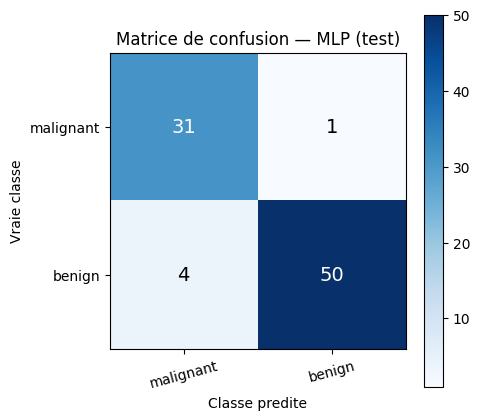

In [13]:
cm = test_metrics["confusion_matrix"]
plt.figure(figsize=(5, 4.5))
plt.imshow(cm, cmap="Blues")
plt.title("Matrice de confusion — MLP (test)")
plt.colorbar()
ticks = range(len(data.class_names))
plt.xticks(ticks, data.class_names, rotation=15)
plt.yticks(ticks, data.class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.ylabel("Vraie classe")
plt.xlabel("Classe predite")
plt.tight_layout()
plt.savefig(FIG / "confusion_matrix.png", dpi=120)

## 9. Comparaison avec les modèles classiques (baselines)

Sur des données **tabulaires** avec peu d'exemples (569), les modèles classiques rivalisent souvent avec le MLP.
C'est une limite connue du deep learning : il brille surtout sur des données non-structurées (images, texte) à grande échelle.

In [14]:
Xtr = data.X_train.numpy(); ytr = data.y_train.numpy()
Xte = data.X_test.numpy();  yte = data.y_test.numpy()

baselines = {}
for name, clf in [
    ("RegLogistique",  LogisticRegression(max_iter=5000)),
    ("ForetAleatoire", RandomForestClassifier(n_estimators=300, random_state=SEED)),
]:
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)
    baselines[name] = {
        "accuracy": float(accuracy_score(yte, pred)),
        "f1":       float(f1_score(yte, pred, average="macro")),
    }
    print(f"  {name:15s}: acc={baselines[name]['accuracy']:.4f}  f1={baselines[name]['f1']:.4f}")

  RegLogistique  : acc=0.9651  f1=0.9629
  ForetAleatoire : acc=0.9186  f1=0.9144


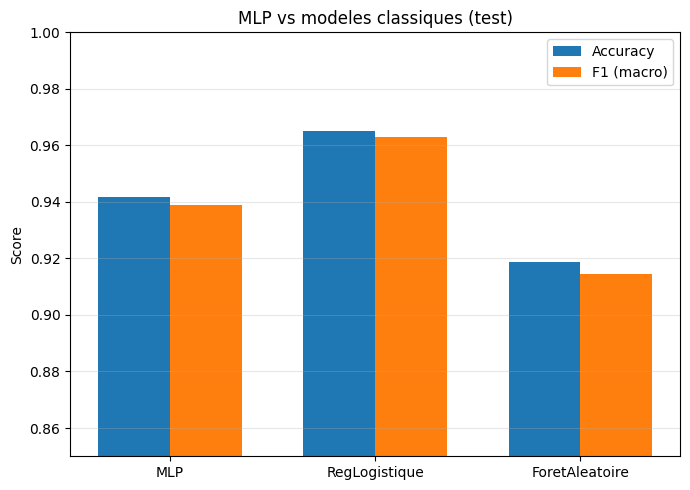

In [15]:
names = ["MLP"] + list(baselines.keys())
accs  = [test_metrics["accuracy"]] + [baselines[n]["accuracy"] for n in baselines]
f1s   = [test_metrics["f1"]]       + [baselines[n]["f1"]       for n in baselines]
x = np.arange(len(names)); w = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - w/2, accs, w, label="Accuracy")
plt.bar(x + w/2, f1s,  w, label="F1 (macro)")
plt.xticks(x, names)
plt.ylim(0.85, 1.0)
plt.ylabel("Score")
plt.title("MLP vs modeles classiques (test)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIG / "mlp_vs_baselines.png", dpi=120)

In [16]:
summary = {
    "device": str(DEVICE),
    "n_parameters": count_parameters(best_model),
    "init_val_accuracy": init_results,
    "best_init": best_init,
    "mlp_test": {k: float(test_metrics[k]) for k in ["accuracy", "precision", "recall", "f1"]},
    "mlp_confusion_matrix": cm.tolist(),
    "baselines_test": baselines,
}
with open(FIG / "metrics.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"[OK] Artefacts ecrits dans {FIG}")
print("Figures : init_comparison, learning_curves, confusion_matrix, mlp_vs_baselines")

[OK] Artefacts ecrits dans /results/part1
Figures : init_comparison, learning_curves, confusion_matrix, mlp_vs_baselines
